# Importing Required Libraries

In [137]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score,mean_squared_error
from sklearn.model_selection import train_test_split

# Loading Dataset

In [77]:
df=sns.load_dataset('diamonds')

In [78]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
#  checking dtype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [ ]:
# statistical summary of the dataset
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [ ]:
# size of the dataset
df.size

539400

In [ ]:
# shape of the dataset
df.shape

(53940, 10)

In [ ]:
# Checking Null Values
df.isnull().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [ ]:
# Duplicates
df.duplicated().sum()

np.int64(146)

In [ ]:
# Droping Duplicates
df.drop_duplicates(inplace=True)

In [ ]:
# size after droping duplicates
df.size

537940

In [ ]:
# unique values in cut column
df['cut'].unique()

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']

In [ ]:
# unique values in cut column
df['color'].unique()

['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']

In [ ]:
# unique values in cut column
df['cut'].unique()
# unique values in color column
df['color'].unique()
# unique values in clarity column
df['clarity'].unique()

['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']

In [ ]:
# checking for zero values in x,y,z columns
(df[['x','y','z']]==0).sum()

,0
x,7
y,6
z,19


In [ ]:
# removing zero values in x,y,z columns
df=df[(df['x']>0) & (df['y']>0) & (df['z']>0)]

In [92]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


# Checking Outliers

In [ ]:
# Checking outliers in Depth Column
q1=df['depth'].quantile(0.25)
q3=df['depth'].quantile(0.75)
IQR=q3-q1
lowerlimit=q1-1.5*IQR
upperlimit=q3+1.5*IQR

In [ ]:
# Count outliers for a column (e.g., 'depth')
num_outliers = ((df['depth'] < lowerlimit) | (df['depth'] > upperlimit)).sum()
print("Number of outliers:", num_outliers)

Number of outliers: 2523


In [ ]:
(df['depth'] > upperlimit).sum()

np.int64(1027)

In [ ]:
# Checking outliers in Table Column
q1=df['table'].quantile(0.25)
q3=df['table'].quantile(0.75)
IQR=q3-q1
lowerlimit=q1-1.5*IQR
upperlimit=q3+1.5*IQR

In [97]:
print(q1)
print(q3)
print(IQR)
print(lowerlimit)
print(upperlimit)

56.0
59.0
3.0
51.5
63.5


In [ ]:
# Checking outliers in x Column
q1=df['x'].quantile(0.25)
q3=df['x'].quantile(0.75)
IQR=q3-q1
lowerlimit=q1-1.5*IQR
upperlimit=q3+1.5*IQR

In [99]:
print(q1)
print(q3)
print(IQR)
print(lowerlimit)
print(upperlimit)

4.71
6.54
1.83
1.9649999999999999
9.285


In [ ]:
# Checking outliers in y Column
q1=df['y'].quantile(0.25)
q3=df['y'].quantile(0.75)
IQR=q3-q1
lowerlimit=q1-1.5*IQR
upperlimit=q3+1.5*IQR

In [101]:
print(q1)
print(q3)
print(IQR)
print(lowerlimit)
print(upperlimit)

4.72
6.54
1.8200000000000003
1.9899999999999993
9.27


In [ ]:
# Checking outliers in y Column
q1=df['z'].quantile(0.25)
q3=df['z'].quantile(0.75)
IQR=q3-q1
lowerlimit=q1-1.5*IQR
upperlimit=q3+1.5*IQR

In [103]:
print(q1)
print(q3)
print(IQR)
print(lowerlimit)
print(upperlimit)

2.91
4.03
1.12
1.23
5.710000000000001


In [ ]:
# Removing Values above upper limit (max limit)
df=df[df['x']<10]
df=df[df['y']<10]
df=df[df['z']<6]
df=df[df['depth']<70]
df=df[df['table']<70]

In [ ]:
# resetting the Index Numbers
df.reset_index(drop=True,inplace=True)

In [106]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53717,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53718,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53719,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53720,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


# Visualizations


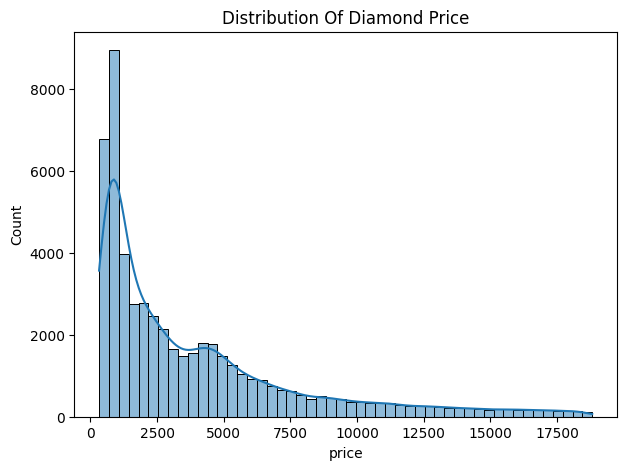

In [107]:
plt.figure(figsize=(7,5))
sns.histplot(df['price'],kde=True,bins=50)
plt.title('Distribution Of Diamond Price')
plt.show()

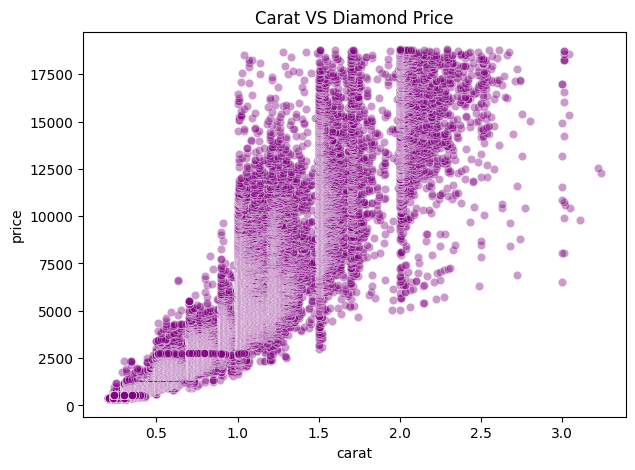

In [108]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x='carat', y='price', data=df, alpha=0.4, color='purple')
plt.title('Carat VS Diamond Price')
plt.show()

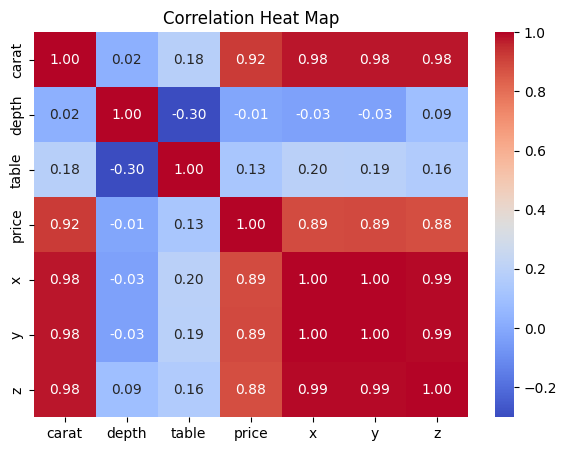

In [109]:
plt.figure(figsize=(7, 5))
# Compute Pearson correlation matrix
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title('Correlation Heat Map')
plt.show()

In [110]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


# Preprocessing

In [111]:
print(df['cut'].unique())
print(df['color'].unique())
print(df['clarity'].unique())

['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']
['E', 'I', 'J', 'H', 'F', 'G', 'D']
Categories (7, object): ['D', 'E', 'F', 'G', 'H', 'I', 'J']
['SI2', 'SI1', 'VS1', 'VS2', 'VVS2', 'VVS1', 'I1', 'IF']
Categories (8, object): ['IF', 'VVS1', 'VVS2', 'VS1', 'VS2', 'SI1', 'SI2', 'I1']


In [ ]:
# Ordinal Encoding for Categorical Columns 
cut_order=['Fair','Good','Very Good','Premium', 'Ideal'  ]
color_order=['J','I','H','G','F','E','D']
clarity_order=['I1', 'SI2','SI1','VS2','VS1','VVS2', 'VVS1','IF']

encoder = OrdinalEncoder(categories=[cut_order,color_order,clarity_order])
df[['cut','color','clarity']]=encoder.fit_transform(df[['cut','color','clarity']])

In [113]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3.0,1.0,3.0,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1.0,0.0,1.0,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53717,0.72,4.0,6.0,2.0,60.8,57.0,2757,5.75,5.76,3.50
53718,0.72,1.0,6.0,2.0,63.1,55.0,2757,5.69,5.75,3.61
53719,0.70,2.0,6.0,2.0,62.8,60.0,2757,5.66,5.68,3.56
53720,0.86,3.0,2.0,1.0,61.0,58.0,2757,6.15,6.12,3.74


In [114]:
df['volume']=df['x']*df['y']*df['z']

In [115]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z,volume
0,0.23,4.0,5.0,1.0,61.5,55.0,326,3.95,3.98,2.43,38.202030
1,0.21,3.0,5.0,2.0,59.8,61.0,326,3.89,3.84,2.31,34.505856
2,0.23,1.0,5.0,4.0,56.9,65.0,327,4.05,4.07,2.31,38.076885
3,0.29,3.0,1.0,3.0,62.4,58.0,334,4.20,4.23,2.63,46.724580
4,0.31,1.0,0.0,1.0,63.3,58.0,335,4.34,4.35,2.75,51.917250
...,...,...,...,...,...,...,...,...,...,...,...
53717,0.72,4.0,6.0,2.0,60.8,57.0,2757,5.75,5.76,3.50,115.920000
53718,0.72,1.0,6.0,2.0,63.1,55.0,2757,5.69,5.75,3.61,118.110175
53719,0.70,2.0,6.0,2.0,62.8,60.0,2757,5.66,5.68,3.56,114.449728
53720,0.86,3.0,2.0,1.0,61.0,58.0,2757,6.15,6.12,3.74,140.766120


In [118]:
df=df.drop(columns=['x','y','z'])

In [119]:
df

,carat,cut,color,clarity,depth,table,price,volume
0,0.23,4.0,5.0,1.0,61.5,55.0,326,38.202030
1,0.21,3.0,5.0,2.0,59.8,61.0,326,34.505856
2,0.23,1.0,5.0,4.0,56.9,65.0,327,38.076885
3,0.29,3.0,1.0,3.0,62.4,58.0,334,46.724580
4,0.31,1.0,0.0,1.0,63.3,58.0,335,51.917250
...,...,...,...,...,...,...,...,...
53717,0.72,4.0,6.0,2.0,60.8,57.0,2757,115.920000
53718,0.72,1.0,6.0,2.0,63.1,55.0,2757,118.110175
53719,0.70,2.0,6.0,2.0,62.8,60.0,2757,114.449728
53720,0.86,3.0,2.0,1.0,61.0,58.0,2757,140.766120


# Model Building

In [ ]:
# Step 1 
x = df.drop('price',axis=1) # independent variable
y = df['price']  # dependent variable

In [121]:
x.head()

,carat,cut,color,clarity,depth,table,volume
0,0.23,4.0,5.0,1.0,61.5,55.0,38.202030
1,0.21,3.0,5.0,2.0,59.8,61.0,34.505856
2,0.23,1.0,5.0,4.0,56.9,65.0,38.076885
3,0.29,3.0,1.0,3.0,62.4,58.0,46.724580
4,0.31,1.0,0.0,1.0,63.3,58.0,51.917250


In [122]:
y.head()

,price
0,326
1,326
2,327
3,334
4,335


# Splitting


In [ ]:

X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [125]:
X_train.head()

,carat,cut,color,clarity,depth,table,volume
48167,0.56,2.0,6.0,3.0,62.8,57.0,91.926975
19822,1.20,4.0,4.0,3.0,62.3,56.0,196.345072
13906,1.09,3.0,2.0,3.0,60.0,56.0,180.724728
48640,0.55,4.0,6.0,3.0,61.8,54.0,90.710804
42842,0.46,3.0,5.0,4.0,61.7,59.0,74.581040


In [126]:
X_test.shape # 20% of Data

(10745, 7)

In [127]:
X_train.shape # 80% of data

(42977, 7)

# Feature Scaling

In [ ]:

scalar=StandardScaler()
X_trained_scaled=scalar.fit_transform(X_train)
X_test_scaled=scalar.transform(X_test)

In [130]:
X_trained_scaled

array([[-0.50372441, -0.81439452,  1.52156265, ...,  0.74711576,
        -0.20201197, -0.49739212],
       [ 0.85425606,  0.98090354,  0.34569777, ...,  0.39222128,
        -0.65432689,  0.8746656 ],
       [ 0.62085316,  0.08325451, -0.83016712, ..., -1.24029333,
        -0.65432689,  0.66941369],
       ...,
       [-0.58859818,  0.98090354, -1.41809957, ...,  0.1792846 ,
        -1.55895675, -0.57354247],
       [-0.01570018,  0.98090354, -0.24223468, ...,  0.60515797,
        -1.10664182,  0.00893715],
       [ 1.4908094 , -2.60969259, -0.83016712, ...,  4.43801836,
         0.70261788,  1.33184577]])

In [131]:
X_test_scaled

array([[ 0.42988716, -1.71204356,  1.52156265, ..., -2.80182904,
         0.25030296,  0.45652106],
       [-0.58859818,  0.08325451,  1.52156265, ...,  0.0373268 ,
         0.25030296, -0.57926737],
       [-0.82200108,  0.98090354,  0.34569777, ..., -0.10463099,
        -0.20201197, -0.81593521],
       ...,
       [ 0.47232405,  0.98090354,  1.52156265, ..., -0.38854657,
        -0.65432689,  0.53929673],
       [-1.05540397,  0.98090354,  0.93363021, ...,  0.25026349,
        -1.73988272, -1.04415598],
       [-1.05540397, -0.81439452, -0.83016712, ..., -1.16931443,
        -1.10664182, -1.03525673]])

# Model Training

In [132]:
model=RandomForestRegressor(n_estimators=200,max_depth=12,random_state=42,n_jobs=-1)
model.fit(X_trained_scaled,y_train)

RandomForestRegressor(max_depth=12, n_estimators=200, n_jobs=-1,
                      random_state=42)

# Prediction

In [133]:
y_pred=model.predict(X_test_scaled)

In [134]:
y_pred

array([4279.22657147, 1830.23009319,  864.37483235, ..., 5882.39203273,
        793.9825885 ,  470.5228647 ])

In [135]:
prediction_df=pd.DataFrame(
   { 'Actual Price':y_test.values,
    'Predicted_price':y_pred}
)

In [136]:
prediction_df

,Actual Price,Predicted_price
0,4218,4279.226571
1,1774,1830.230093
2,904,864.374832
3,506,561.297704
4,4513,4938.989199
...,...,...
10740,11088,10439.442449
10741,5884,3813.818324
10742,6040,5882.392033
10743,652,793.982589


In [140]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

In [141]:
print(mae)
print(mse)
print(r2)

279.76826949783054
293308.19407897524
0.9812134274978694


Extracted Values (from Output [141])
- MAE (Mean Absolute Error): 279.77(On average, your price predictions are off by ~$279.77)

- MSE (Mean Squared Error): 293,308.19
- R^2$ Score (Coefficient of Determination)
: 0.9812 (or 98.12%)(Your model explains ~98.12% of the variance in diamond prices)

In [142]:
# r2 --- proportion (0 to 1) of the variance in price that the model...
# explain 0.98 means the model's feature explain 98% of what determines price correctly